# ASSIGMENT-3

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Part 1: Data Exploration

### 1. Load the dataset and review its structure.

In [3]:
df = pd.read_csv('Employee.csv')

In [4]:
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [5]:
df.shape

(4653, 9)

### 2. Identify the categorical and numerical features.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


#### => 'Education', 'City', 'Gender', and 'EverBenched' are categorical features, and remaining are numerical features

### 3. Check for missing values.

In [7]:
df.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

#### => No Missing Values Found!

### 4. Compute summary statistics for numerical features (Age, PaymentTier, ExperienceInCurrentDomain).

In [8]:
df_numerical = df[['Age', 'PaymentTier', 'ExperienceInCurrentDomain']]
df_numerical.describe()

,Age,PaymentTier,ExperienceInCurrentDomain
count,4653.000000,4653.000000,4653.000000
mean,29.393295,2.698259,2.905652
std,4.826087,0.561435,1.558240
min,22.000000,1.000000,0.000000
25%,26.000000,3.000000,2.000000
50%,28.000000,3.000000,3.000000
75%,32.000000,3.000000,4.000000
max,41.000000,3.000000,7.000000


### 5. Analyze the distribution of categorical features (Education, City, Gender, EverBenched).

In [9]:
df['Education'].count()

np.int64(4653)

In [10]:
df['Education'].value_counts()

Education
Bachelors    3601
Masters       873
PHD           179
Name: count, dtype: int64

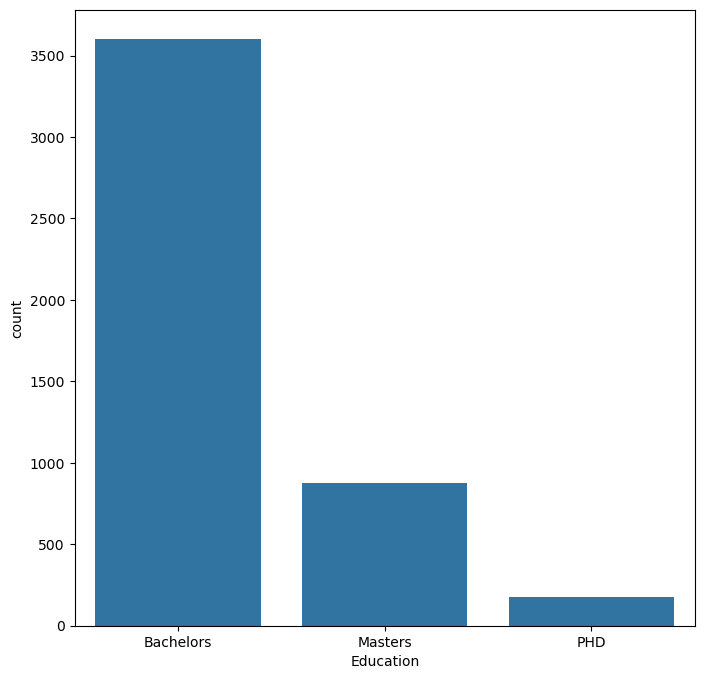

In [11]:
plt.figure(figsize=(8,8))
sns.countplot(x="Education", data=df)
plt.show()

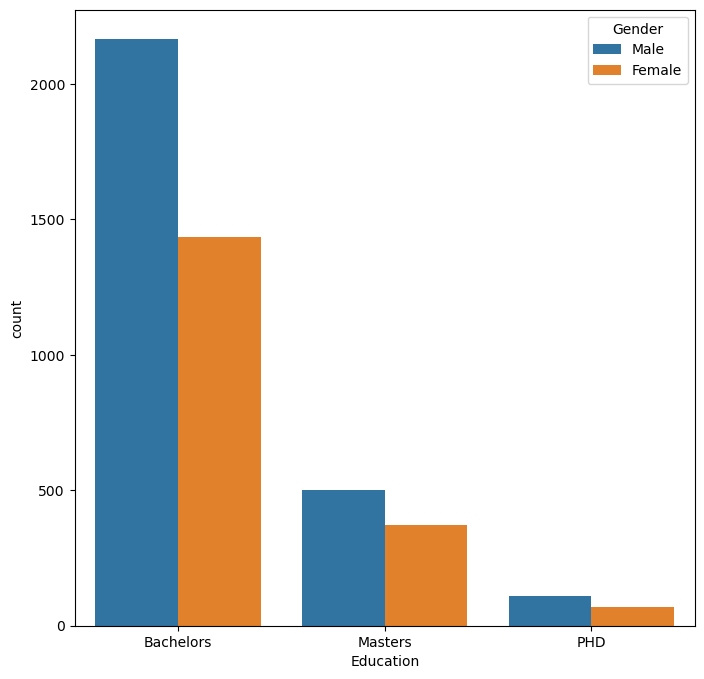

In [12]:
plt.figure(figsize=(8,8))
sns.countplot(x="Education", hue='Gender', data=df)
plt.show()

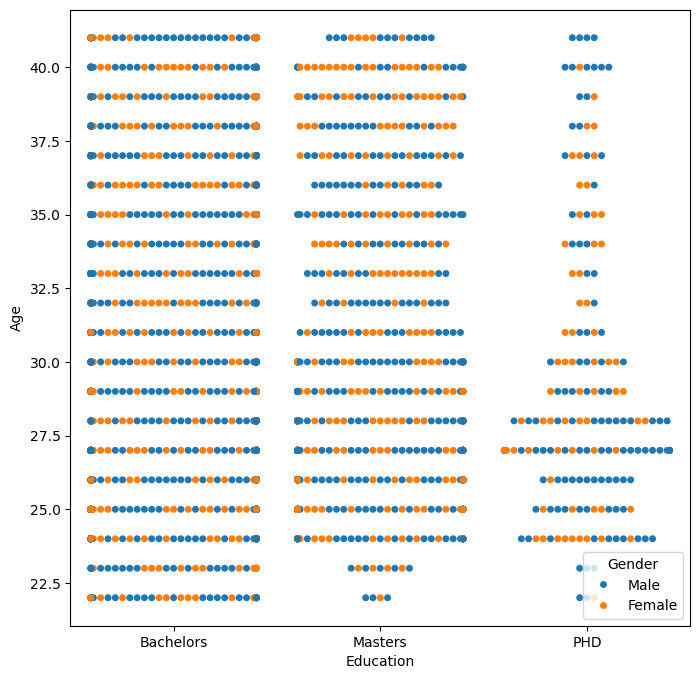

In [13]:
plt.figure(figsize=(8,8))
sns.swarmplot(x="Education", y='Age', hue='Gender', data=df)
plt.show()

In [14]:
df['City'].unique()

array(['Bangalore', 'Pune', 'New Delhi'], dtype=object)

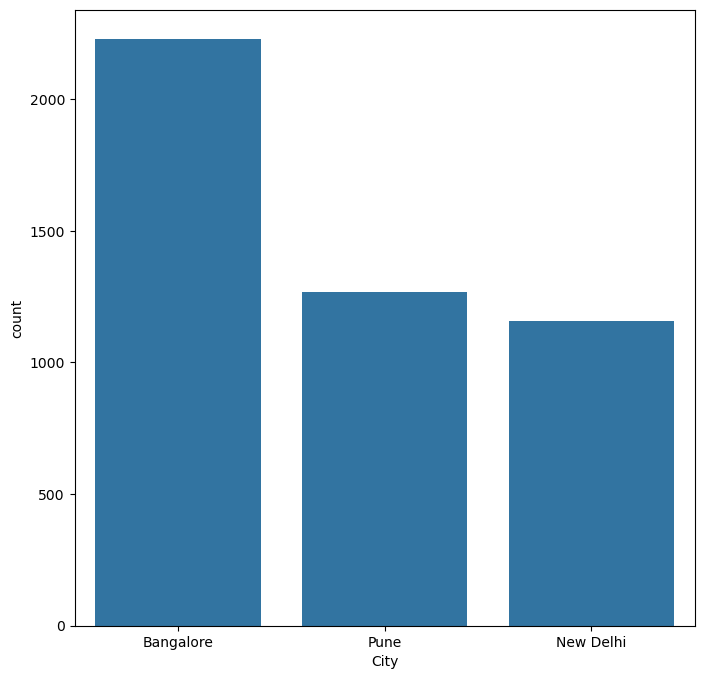

In [15]:
plt.figure(figsize=(8,8))
sns.countplot(x="City", data=df)
plt.show()

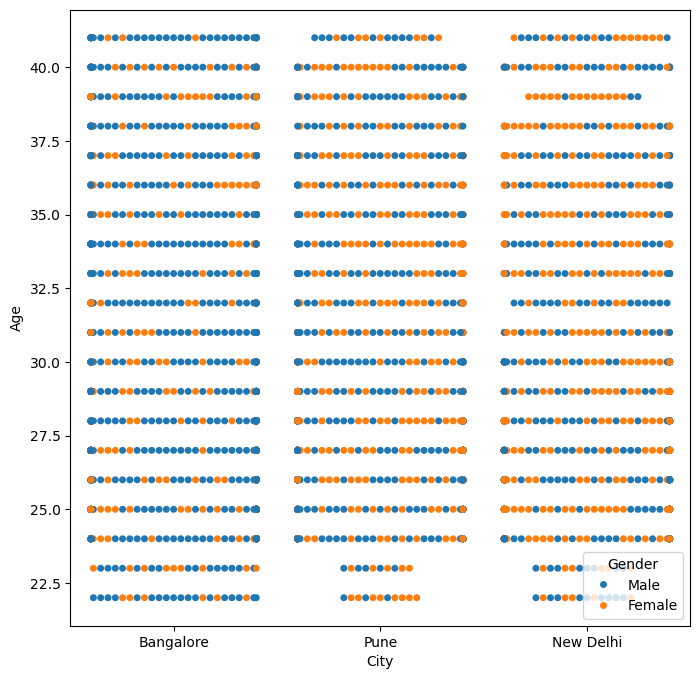

In [16]:
plt.figure(figsize=(8,8))
sns.swarmplot(x="City", y='Age', hue='Gender', data=df)
plt.show()

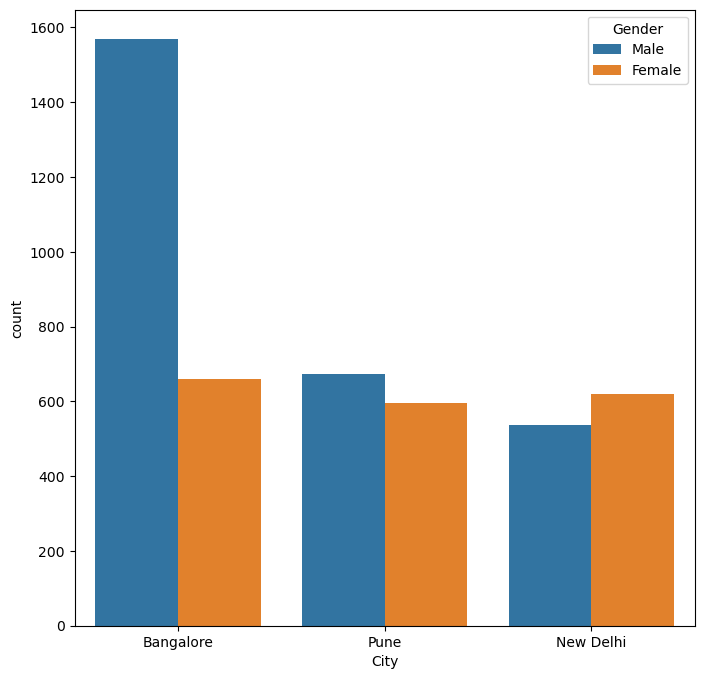

In [17]:
plt.figure(figsize=(8,8))
sns.countplot(x="City", hue='Gender', data=df)
plt.show()

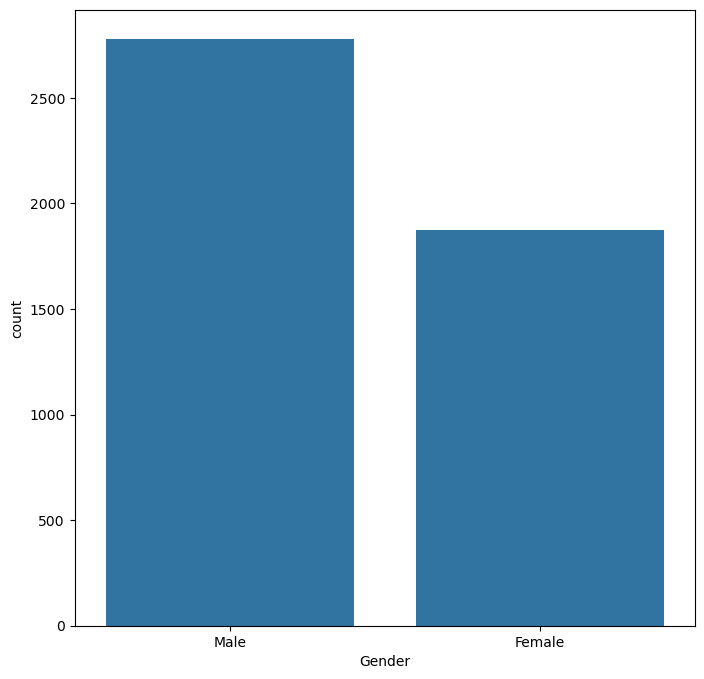

In [18]:
plt.figure(figsize=(8,8))
sns.countplot(x="Gender", data=df)
plt.show()

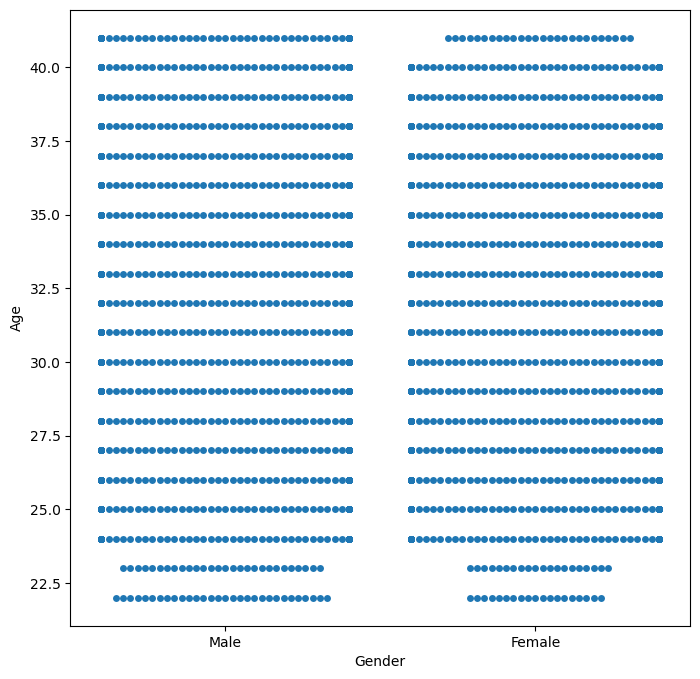

In [19]:
plt.figure(figsize=(8,8))
sns.swarmplot(x="Gender", y='Age', data=df)
plt.show()

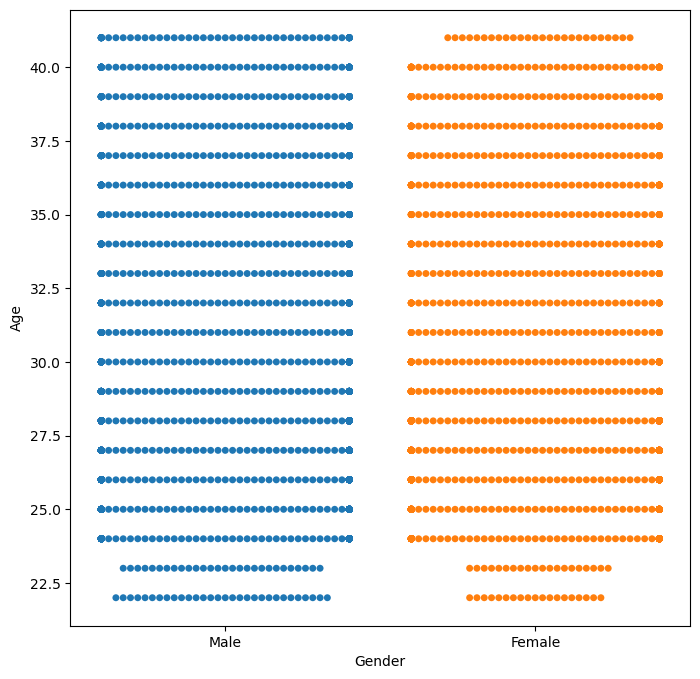

In [20]:
plt.figure(figsize=(8,8))
sns.swarmplot(x="Gender", y='Age', hue='Gender', data=df)
plt.show()

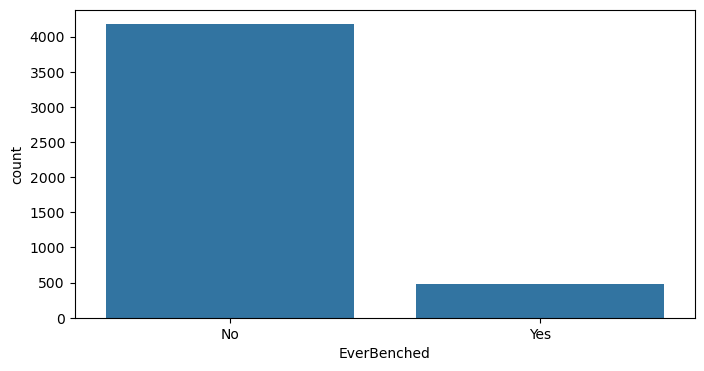

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(x="EverBenched", data=df)
plt.show()

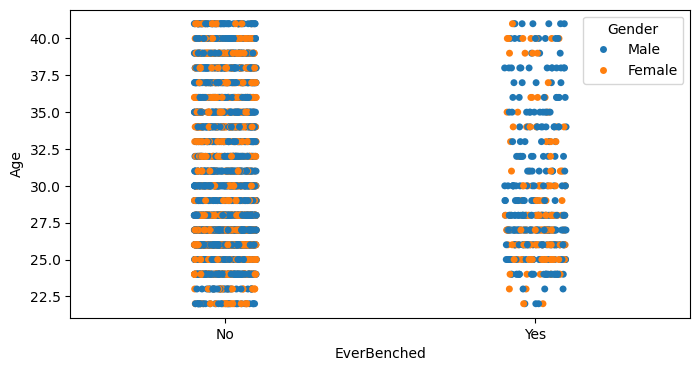

In [22]:
plt.figure(figsize=(8,4))
sns.stripplot(x="EverBenched", y="Age", hue='Gender', data=df)
plt.show()

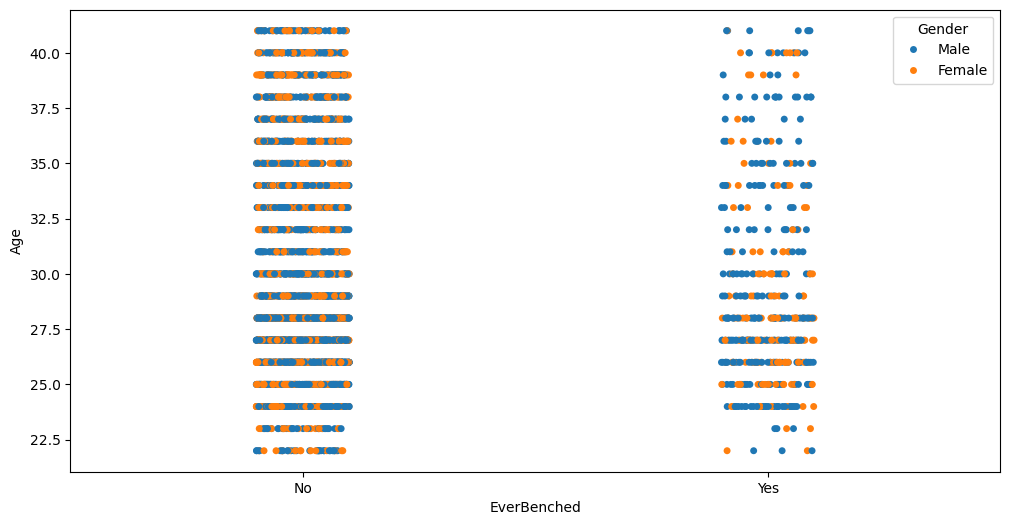

In [23]:
plt.figure(figsize=(12,6))
sns.stripplot(x="EverBenched", y="Age", hue='Gender', data=df)
plt.show()

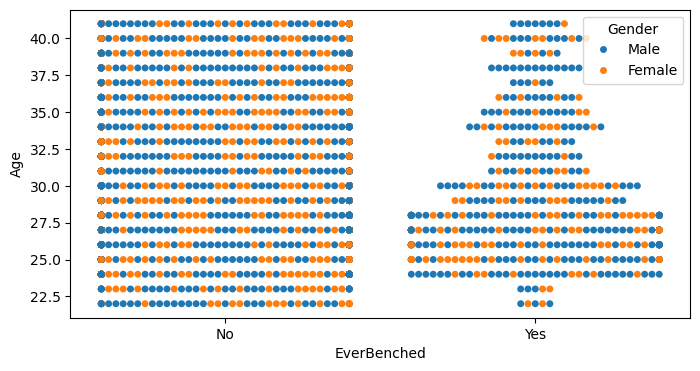

In [24]:
plt.figure(figsize=(8,4))
sns.swarmplot(x="EverBenched", y="Age", hue='Gender', data=df)
plt.show()

### 6. Plot or visualize the distribution of the target variable LeaveOrNot.

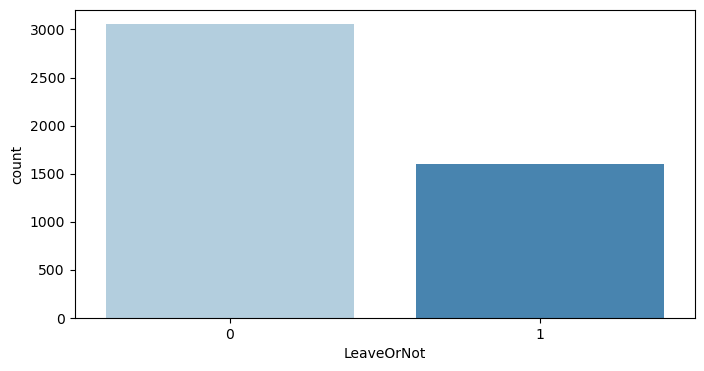

In [25]:
plt.figure(figsize=(8,4))
sns.countplot(x="LeaveOrNot", data=df, palette="Blues");
plt.show()

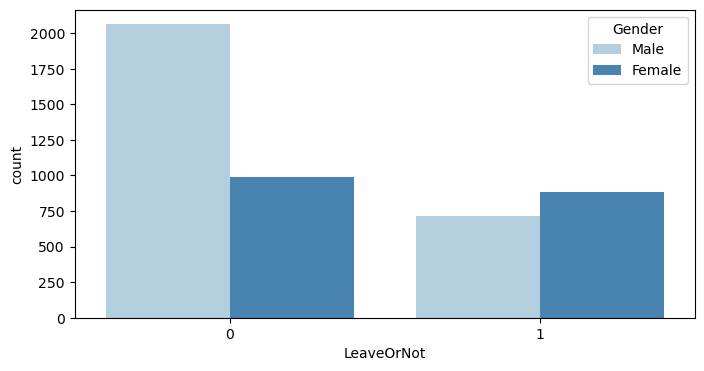

In [26]:
plt.figure(figsize=(8,4))
sns.countplot(x="LeaveOrNot", hue='Gender', data=df, palette="Blues");
plt.show()

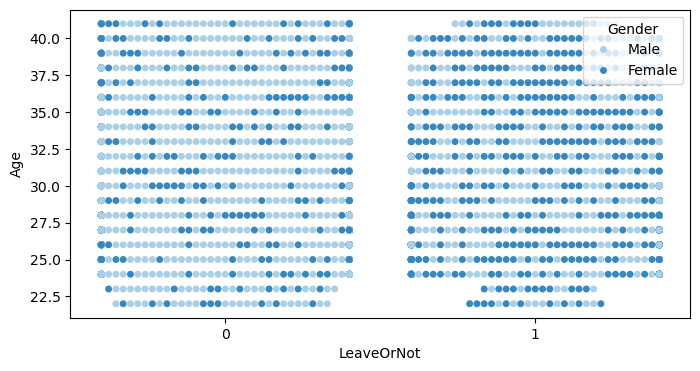

In [27]:
plt.figure(figsize=(8,4))
sns.swarmplot(x="LeaveOrNot", y='Age', hue='Gender', data=df, palette="Blues");
plt.show()

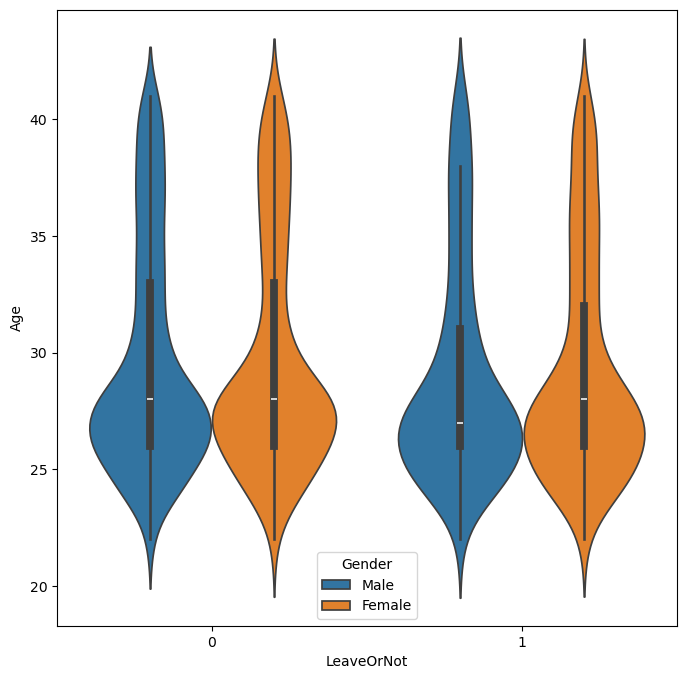

In [28]:
plt.figure(figsize=(8,8))
sns.violinplot(x="LeaveOrNot", y="Age", hue='Gender', data=df)
plt.show()

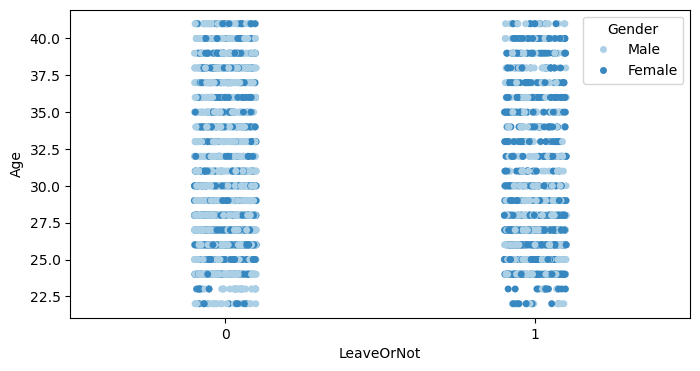

In [29]:
plt.figure(figsize=(8,4))
sns.stripplot(x="LeaveOrNot", y='Age', hue='Gender', data=df, palette="Blues");
plt.show()

## Part 2: Data Preprocessing

### 1. Encode categorical features (Education, City, Gender, EverBenched) appropriately.

In [30]:
df.dtypes

Education                    object
JoiningYear                   int64
City                         object
PaymentTier                   int64
Age                           int64
Gender                       object
EverBenched                  object
ExperienceInCurrentDomain     int64
LeaveOrNot                    int64
dtype: object

In [31]:
df.select_dtypes(['object']).columns

Index(['Education', 'City', 'Gender', 'EverBenched'], dtype='object')

In [32]:
# Convert objects to category data type
cat_col = ['Education', 'City', 'Gender', 'EverBenched']

for colname in cat_col:
    df[colname] = df[colname].astype('category')

In [33]:
df.select_dtypes(['category']).columns

Index(['Education', 'City', 'Gender', 'EverBenched'], dtype='object')

In [34]:
df.dtypes

Education                    category
JoiningYear                     int64
City                         category
PaymentTier                     int64
Age                             int64
Gender                       category
EverBenched                  category
ExperienceInCurrentDomain       int64
LeaveOrNot                      int64
dtype: object

In [35]:
# Convert categorical variables into 'dummy' or indicator variables
education = pd.get_dummies(df['Education'], drop_first = True) # drop_first prevents multi-collinearity
city = pd.get_dummies(df['City'], drop_first = True)
gender = pd.get_dummies(df['Gender'], drop_first = True)
everBenched = pd.get_dummies(df['EverBenched'], drop_first = True)

In [36]:
education

,Masters,PHD
0,False,False
1,False,False
2,False,False
3,True,False
4,True,False
...,...,...
4648,False,False
4649,True,False
4650,True,False
4651,False,False


In [37]:
gender

,Male
0,True
1,False
2,False
3,True
4,True
...,...
4648,False
4649,True
4650,True
4651,True


In [38]:
# Add new dummy columns to data frame
df = pd.concat([df, education, city, gender, everBenched], axis = 1)
df.head(5)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,Masters,PHD,New Delhi,Pune,Male,Yes
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,False,False,False,False,True,False
1,Bachelors,2013,Pune,1,28,Female,No,3,1,False,False,False,True,False,False
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,False,False,True,False,False,False
3,Masters,2016,Bangalore,3,27,Male,No,5,1,True,False,False,False,True,False
4,Masters,2017,Pune,3,24,Male,Yes,2,1,True,False,False,True,True,True


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Education                  4653 non-null   category
 1   JoiningYear                4653 non-null   int64   
 2   City                       4653 non-null   category
 3   PaymentTier                4653 non-null   int64   
 4   Age                        4653 non-null   int64   
 5   Gender                     4653 non-null   category
 6   EverBenched                4653 non-null   category
 7   ExperienceInCurrentDomain  4653 non-null   int64   
 8   LeaveOrNot                 4653 non-null   int64   
 9   Masters                    4653 non-null   bool    
 10  PHD                        4653 non-null   bool    
 11  New Delhi                  4653 non-null   bool    
 12  Pune                       4653 non-null   bool    
 13  Male                       4653 n

In [40]:
df.shape

(4653, 15)

In [41]:
# Drop unecessary columns
df.drop(['Education', 'City', 'Gender', 'EverBenched'], axis = 1, inplace = True)
df.head(5)

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,Masters,PHD,New Delhi,Pune,Male,Yes
0,2017,3,34,0,0,False,False,False,False,True,False
1,2013,1,28,3,1,False,False,False,True,False,False
2,2014,3,38,2,0,False,False,True,False,False,False
3,2016,3,27,5,1,True,False,False,False,True,False
4,2017,3,24,2,1,True,False,False,True,True,True


In [42]:
df.shape

(4653, 11)

### 2. Handle scaling of numerical features if needed (Age, ExperienceInCurrentDomain, JoiningYear, PaymentTier).

In [43]:
x = df.drop('LeaveOrNot', axis = 1) # grabs everything else but 'LeaveOrNot' column

y = df['LeaveOrNot'] # y is the column we're trying to predict

In [44]:
x.shape, y.shape

((4653, 10), (4653,))

In [45]:
y

0       0
1       1
2       0
3       1
4       1
       ..
4648    0
4649    1
4650    1
4651    0
4652    0
Name: LeaveOrNot, Length: 4653, dtype: int64

In [46]:
x

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,Masters,PHD,New Delhi,Pune,Male,Yes
0,2017,3,34,0,False,False,False,False,True,False
1,2013,1,28,3,False,False,False,True,False,False
2,2014,3,38,2,False,False,True,False,False,False
3,2016,3,27,5,True,False,False,False,True,False
4,2017,3,24,2,True,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...
4648,2013,3,26,4,False,False,False,False,False,False
4649,2013,2,37,2,True,False,False,True,True,False
4650,2018,3,27,5,True,False,True,False,True,False
4651,2012,3,30,2,False,False,False,False,True,True


In [47]:
from sklearn import preprocessing
pre_process = preprocessing.StandardScaler().fit(x)
x_transform = pre_process.fit_transform(x)

In [48]:
x_transform

array([[ 1.03963837,  0.53750299,  0.95464513, ..., -0.61204068,
         0.82155097, -0.33836521],
       [-1.10723275, -3.0251771 , -0.28873172, ...,  1.63387832,
        -1.21720992, -0.33836521],
       [-0.57051497,  0.53750299,  1.78356303, ..., -0.61204068,
        -1.21720992, -0.33836521],
       ...,
       [ 1.57635615,  0.53750299, -0.49596119, ..., -0.61204068,
         0.82155097, -0.33836521],
       [-1.64395053,  0.53750299,  0.12572723, ..., -0.61204068,
         0.82155097,  2.95538654],
       [-0.03379719,  0.53750299,  0.74741565, ..., -0.61204068,
         0.82155097,  2.95538654]], shape=(4653, 10))

### 3. Split the dataset into training and testing sets (suggested: 80%-20%).

In [49]:
# Use x and y variables to split the training data into train and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = .20, random_state = 101)

In [50]:
x_train.shape, x_test.shape

((3722, 10), (931, 10))

In [51]:
y_train.shape, y_test.shape

((3722,), (931,))

## Part 3 and 4: Model Building & Evaluation

### 1. Decision Tree Classifier

##### Model Training

In [52]:
from sklearn.tree import DecisionTreeClassifier

print('Decision Tree Classifier')
# Create instance of model
Dtree = DecisionTreeClassifier()

# Pass training data into model
Dtree.fit(x_train, y_train)

Decision Tree Classifier


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Model Evaluation

In [53]:
from sklearn.metrics import accuracy_score
# prediction from the model
y_pred_Dtree = Dtree.predict(x_test)
# Score It

print('Decision Tree Classifier')
# Accuracy
print('--'*30)
Dtree_accuracy = round(accuracy_score(y_test, y_pred_Dtree) * 100,2)
print('Accuracy', Dtree_accuracy,'%')

Decision Tree Classifier
------------------------------------------------------------
Accuracy 81.1 %


### 2. Random Forest 

#### Model Training

In [54]:
from sklearn.ensemble import RandomForestClassifier

print('Random Forest Classifier')
# Create instance of model
rfc = RandomForestClassifier()

# Pass training data into model
rfc.fit(x_train, y_train)

Random Forest Classifier


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Model Evaluation

In [55]:
# prediction from the model
y_pred_rfc = rfc.predict(x_test)
# Score It

print('Random Forest Classifier')
# Accuracy
print('--'*30)
rfc_accuracy = round(accuracy_score(y_test, y_pred_rfc) * 100,2)
print('Accuracy', rfc_accuracy,'%')

Random Forest Classifier
------------------------------------------------------------
Accuracy 83.03 %


### 3. Logestic Regression

#### Model Training

In [56]:
# Import model
from sklearn.linear_model import LogisticRegression

print('Logistic Regression')
# Create instance of model
log_reg = LogisticRegression()

# Pass training data into model
log_reg.fit(x_train, y_train)

Logistic Regression


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Model Evaluation 

In [57]:
from sklearn.metrics import accuracy_score
# prediction from the model
y_pred_log_reg = log_reg.predict(x_test)
# Score It

print('Logistic Regression')
# Accuracy
print('--'*30)
log_reg_accuracy = round(accuracy_score(y_test, y_pred_log_reg) * 100,2)
print('Accuracy', log_reg_accuracy,'%')

Logistic Regression
------------------------------------------------------------
Accuracy 76.26 %


## Part 5: Analysis Questions

### 1. Which features are most important in predicting employee attrition?

#### => The important features includes, JoiningYear, PaymentTier, Education, City,	Gender, and EverBenched

### 2. How do Age and ExperienceInCurrentDomain affect the likelihood of leaving?

#### Affect of Age on LeaveOrNot

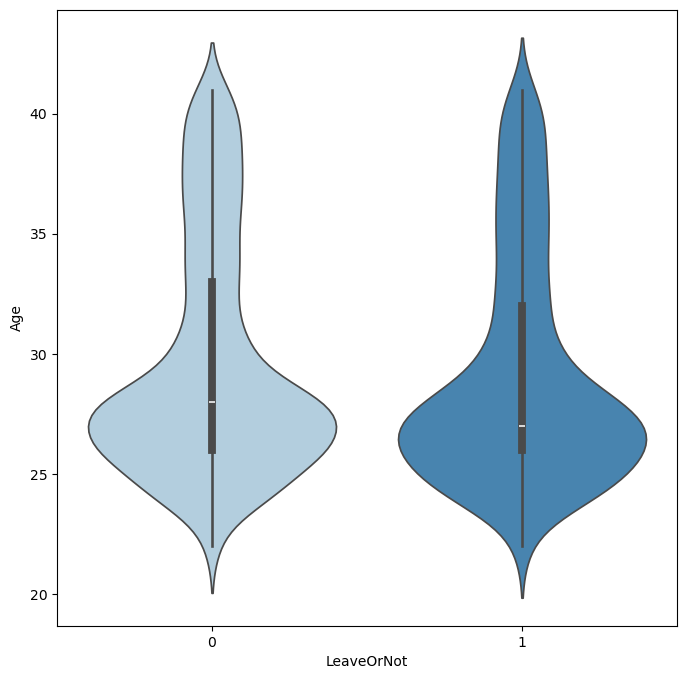

In [61]:
plt.figure(figsize=(8,8))
sns.violinplot(x="LeaveOrNot", y="Age", data=df, palette="Blues")
plt.show()

#### Seems like 'Age' does not affect (:P) 'LeaveOrNot' BECAUSE both the graphs are same

#### Affect of ExperienceInCurrentDomain on LeaveOrNot

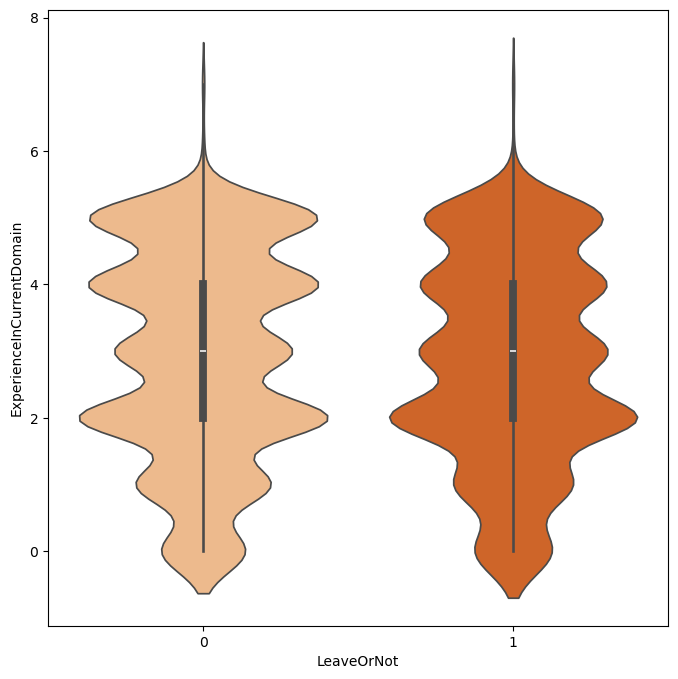

In [63]:
plt.figure(figsize=(8,8))
sns.violinplot(x="LeaveOrNot", y="ExperienceInCurrentDomain", data=df, palette="Oranges")
plt.show()

#### Seems like 'ExperienceInCurrentDomain' ALSO does not affect (:P) 'LeaveOrNot' BECAUSE both the graphs are same!
## Ma'am, I'm not sure about this (How do Age and ExperienceInCurrentDomain affect the likelihood of leaving?). Kindly confirm this in the comment. 

### 3. Compare Decision Tree and Random Forest results. Which model performs better and why?

In [59]:
model_scores = {
    "Decision Tree Classifier": Dtree_accuracy,
    "Random Forest Classifier": rfc_accuracy,
}

# Sort the model scores in descending order based on their values (higher values first)
sorted_scores = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)

# Display the ranking of the models
print("Model Rankings (Greater Values are better):")
for rank, (model_name, score) in enumerate(sorted_scores, start=1):
    print(f"{rank}. {model_name}: {score}")

Model Rankings (Greater Values are better):
1. Random Forest Classifier: 83.03
2. Decision Tree Classifier: 81.1


#### => Random Forest Classifier performs better because its ensemble approach reduces overfitting, lowers variance, and provides better generalization to unseen employee data.

### 4. Suggest HR strategies based on your analysis.

#### => Focus on retaining younger and less-experienced employees through mentorship, career development programs, and clear growth opportunities. Improve compensation competitiveness and reduce bench time by ensuring timely project allocation and continuous upskilling. Tailor retention initiatives based on employee location and predicted attrition risk.